In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("HEALTHCARE ANALYTICS - ADVANCED BUSINESS INTELLIGENCE")
print("=" * 65)

HEALTHCARE ANALYTICS - ADVANCED BUSINESS INTELLIGENCE


In [2]:
# Load all datasets
patients = pd.read_csv(r"C:\Users\Abhin\OneDrive\Documents\healthcare-analytics-portfolio\patients.csv")
doctors = pd.read_csv(r"C:\Users\Abhin\OneDrive\Documents\healthcare-analytics-portfolio\doctors.csv") 
appointments = pd.read_csv(r"C:\Users\Abhin\OneDrive\Documents\healthcare-analytics-portfolio\appointments.csv")
treatments = pd.read_csv(r"C:\Users\Abhin\OneDrive\Documents\healthcare-analytics-portfolio\treatments.csv")
billing = pd.read_csv(r"C:\Users\Abhin\OneDrive\Documents\healthcare-analytics-portfolio\billing.csv")

print("\nSTEP 1: DATA PREPARATION AND FEATURE ENGINEERING")
print("-" * 55)

# Convert date columns
patients['birth_date'] = pd.to_datetime(patients['date_of_birth'])
patients['registration_date_clean'] = pd.to_datetime(patients['registration_date'])
appointments['appointment_datetime'] = pd.to_datetime(appointments['appointment_date'] + ' ' + appointments['appointment_time'])
appointments['appointment_date_clean'] = pd.to_datetime(appointments['appointment_date'])
treatments['treatment_date_clean'] = pd.to_datetime(treatments['treatment_date'])
billing['bill_date_clean'] = pd.to_datetime(billing['bill_date'])

# Calculate patient ages
patients['age'] = (datetime.now() - patients['birth_date']).dt.days / 365.25

# Feature engineering for appointments
appointments['hour'] = appointments['appointment_datetime'].dt.hour
appointments['day_of_week'] = appointments['appointment_datetime'].dt.dayofweek
appointments['month'] = appointments['appointment_datetime'].dt.month
appointments['is_weekend'] = appointments['day_of_week'].isin([5, 6])

# Create master dataset by merging key information
master_df = appointments.merge(patients[['patient_id', 'age', 'gender', 'insurance_provider']], on='patient_id', how='left')
master_df = master_df.merge(doctors[['doctor_id', 'specialization', 'years_experience']], on='doctor_id', how='left')
master_df = master_df.merge(treatments[['appointment_id', 'treatment_type', 'cost']], on='appointment_id', how='left')

print("Master dataset created with shape:", master_df.shape)


STEP 1: DATA PREPARATION AND FEATURE ENGINEERING
-------------------------------------------------------
Master dataset created with shape: (200, 20)


In [3]:
print("\nSTEP 2: NO-SHOW PREDICTION MODEL")
print("-" * 40)

# Create binary target variable (1 = No-show/Cancelled, 0 = Completed/Scheduled)
master_df['is_no_show'] = master_df['status'].isin(['No-show', 'Cancelled']).astype(int)

# Prepare features for machine learning
feature_columns = ['age', 'hour', 'day_of_week', 'month', 'years_experience', 'cost']
categorical_columns = ['gender', 'insurance_provider', 'specialization', 'reason_for_visit']

# Create a modeling dataset
model_data = master_df[feature_columns + categorical_columns + ['is_no_show']].copy()

# Handle categorical variables
le_dict = {}
for col in categorical_columns:
    le = LabelEncoder()
    model_data[col + '_encoded'] = le.fit_transform(model_data[col].astype(str))
    le_dict[col] = le

# Final feature set
final_features = feature_columns + [col + '_encoded' for col in categorical_columns]
X = model_data[final_features]
y = model_data['is_no_show']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Model performance
y_pred = rf_model.predict(X_test)
print("No-Show Prediction Model Performance:")
print(classification_report(y_test, y_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': final_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Factors Predicting No-Shows:")
for idx, row in feature_importance.head().iterrows():
    print(f"• {row['feature']}: {row['importance']:.3f}")


STEP 2: NO-SHOW PREDICTION MODEL
----------------------------------------
No-Show Prediction Model Performance:
              precision    recall  f1-score   support

           0       0.52      0.52      0.52        29
           1       0.55      0.55      0.55        31

    accuracy                           0.53        60
   macro avg       0.53      0.53      0.53        60
weighted avg       0.53      0.53      0.53        60


Top 5 Factors Predicting No-Shows:
• cost: 0.177
• age: 0.161
• hour: 0.127
• month: 0.123
• reason_for_visit_encoded: 0.106


In [4]:
print("\nSTEP 3: REVENUE ANALYSIS AND OPTIMIZATION")
print("-" * 45)

# Revenue by appointment status
revenue_by_status = master_df.groupby('status').agg({
    'cost': ['count', 'sum', 'mean']
}).round(2)
revenue_by_status.columns = ['appointment_count', 'total_revenue', 'avg_revenue']

print("Revenue Analysis by Appointment Status:")
print(revenue_by_status)

# Calculate lost revenue opportunity
completed_revenue = revenue_by_status.loc['Completed', 'total_revenue']
total_potential_revenue = master_df['cost'].sum()
lost_revenue = total_potential_revenue - completed_revenue

print(f"\nRevenue Opportunity Analysis:")
print(f"• Completed appointments revenue: ${completed_revenue:,.2f}")
print(f"• Total potential revenue: ${total_potential_revenue:,.2f}")
print(f"• Lost revenue opportunity: ${lost_revenue:,.2f}")
print(f"• Revenue recovery potential: {(lost_revenue/total_potential_revenue)*100:.1f}%")

# Revenue by specialization
specialty_revenue = master_df.groupby('specialization').agg({
    'cost': ['count', 'sum', 'mean'],
    'is_no_show': 'mean'
}).round(2)
specialty_revenue.columns = ['appointments', 'total_revenue', 'avg_revenue_per_appt', 'no_show_rate']

print(f"\nRevenue Analysis by Medical Specialization:")
print(specialty_revenue)

# Payment method analysis
payment_analysis = billing.groupby('payment_method').agg({
    'amount': ['count', 'sum', 'mean']
}).round(2)
payment_analysis.columns = ['bill_count', 'total_amount', 'avg_amount']

print(f"\nPayment Method Analysis:")
print(payment_analysis)


STEP 3: REVENUE ANALYSIS AND OPTIMIZATION
---------------------------------------------
Revenue Analysis by Appointment Status:
           appointment_count  total_revenue  avg_revenue
status                                                  
Cancelled                 51      152044.88      2981.27
Completed                 46      124100.46      2697.84
No-show                   52      142677.81      2743.80
Scheduled                 51      132426.70      2596.60

Revenue Opportunity Analysis:
• Completed appointments revenue: $124,100.46
• Total potential revenue: $551,249.85
• Lost revenue opportunity: $427,149.39
• Revenue recovery potential: 77.5%

Revenue Analysis by Medical Specialization:
                appointments  total_revenue  avg_revenue_per_appt  \
specialization                                                      
Dermatology               70      202709.29               2895.85   
Oncology                  32       89602.73               2800.09   
Pediatrics      

In [5]:
print("\nSTEP 4: OPERATIONAL EFFICIENCY ANALYSIS")
print("-" * 45)

# Peak demand analysis
demand_by_hour = master_df.groupby('hour').size()
demand_by_day = master_df.groupby('day_of_week').size()
demand_by_month = master_df.groupby('month').size()

print("Peak Demand Analysis:")
print(f"• Busiest hour: {demand_by_hour.idxmax()}:00 ({demand_by_hour.max()} appointments)")
print(f"• Busiest day: {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][demand_by_day.idxmax()]} ({demand_by_day.max()} appointments)")
print(f"• Busiest month: Month {demand_by_month.idxmax()} ({demand_by_month.max()} appointments)")

# Doctor utilization analysis
doctor_utilization = master_df.groupby(['doctor_id', 'specialization']).agg({
    'appointment_id': 'count',
    'is_no_show': 'mean',
    'cost': 'sum'
}).round(2)
doctor_utilization.columns = ['total_appointments', 'no_show_rate', 'total_revenue']
doctor_utilization = doctor_utilization.sort_values('total_appointments', ascending=False)

print(f"\nDoctor Utilization Analysis:")
print(doctor_utilization.head())

# Patient journey analysis
patient_journey = master_df.groupby('patient_id').agg({
    'appointment_id': 'count',
    'is_no_show': 'mean',
    'cost': 'sum'
}).round(2)
patient_journey.columns = ['total_appointments', 'no_show_rate', 'total_spent']

print(f"\nPatient Engagement Metrics:")
print(f"• Average appointments per patient: {patient_journey['total_appointments'].mean():.1f}")
print(f"• Patients with multiple appointments: {(patient_journey['total_appointments'] > 1).sum()}")
print(f"• High-value patients (>$5000): {(patient_journey['total_spent'] > 5000).sum()}")


STEP 4: OPERATIONAL EFFICIENCY ANALYSIS
---------------------------------------------
Peak Demand Analysis:
• Busiest hour: 15:00 (28 appointments)
• Busiest day: Tue (37 appointments)
• Busiest month: Month 4 (25 appointments)

Doctor Utilization Analysis:
                          total_appointments  no_show_rate  total_revenue
doctor_id specialization                                                 
D005      Dermatology                     29          0.52       82696.48
D001      Dermatology                     25          0.56       66585.39
D006      Pediatrics                      24          0.50       69586.10
D003      Pediatrics                      22          0.50       52791.41
D002      Pediatrics                      21          0.43       59803.46

Patient Engagement Metrics:
• Average appointments per patient: 4.2
• Patients with multiple appointments: 48
• High-value patients (>$5000): 44



STEP 5: CREATING ADVANCED VISUALIZATIONS
---------------------------------------------


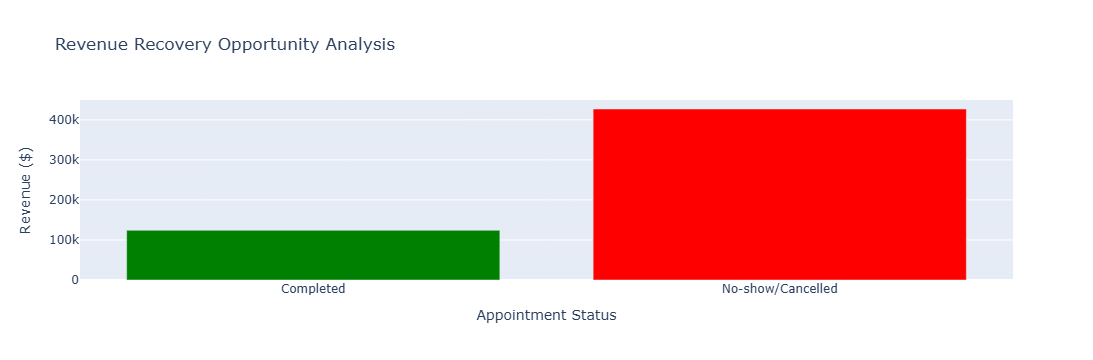

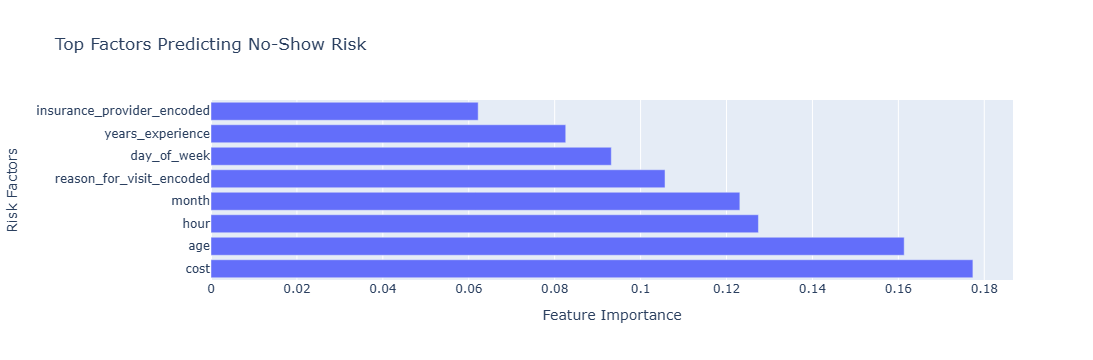

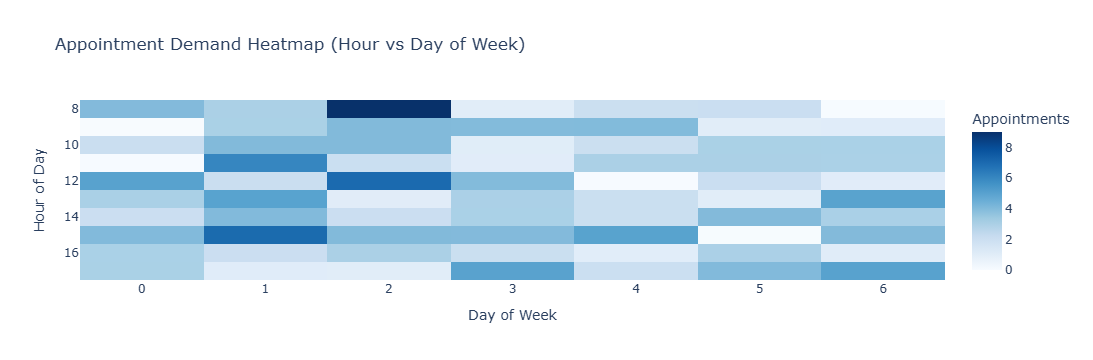

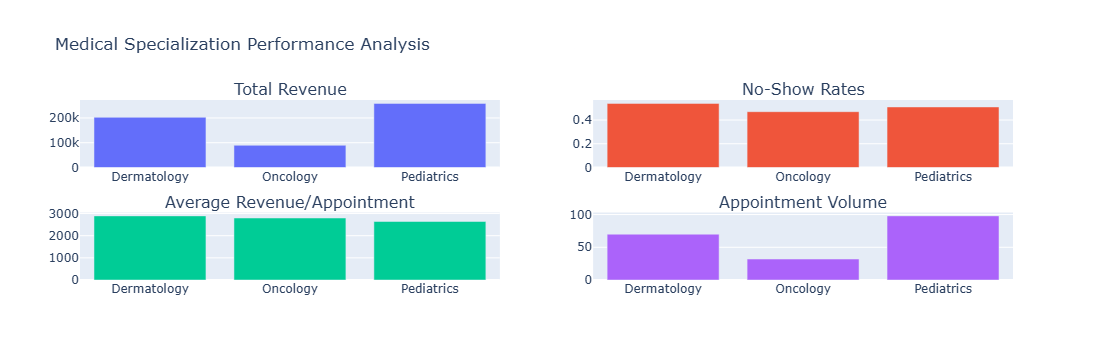

In [6]:
print("\nSTEP 5: CREATING ADVANCED VISUALIZATIONS")
print("-" * 45)

# 1. Revenue Recovery Opportunity Visualization
fig_revenue = go.Figure()

# Add current revenue
fig_revenue.add_trace(go.Bar(
    name='Current Revenue',
    x=['Completed', 'No-show/Cancelled'],
    y=[completed_revenue, lost_revenue],
    marker_color=['green', 'red']
))

fig_revenue.update_layout(
    title='Revenue Recovery Opportunity Analysis',
    xaxis_title='Appointment Status',
    yaxis_title='Revenue ($)',
    showlegend=False
)

fig_revenue.show()

# 2. No-Show Risk Factors
fig_factors = px.bar(
    feature_importance.head(8),
    x='importance',
    y='feature',
    orientation='h',
    title='Top Factors Predicting No-Show Risk',
    labels={'importance': 'Feature Importance', 'feature': 'Risk Factors'}
)
fig_factors.show()

# 3. Demand Heatmap by Hour and Day
demand_heatmap = master_df.pivot_table(
    values='appointment_id',
    index='hour',
    columns='day_of_week',
    aggfunc='count',
    fill_value=0
)

fig_heatmap = px.imshow(
    demand_heatmap,
    title='Appointment Demand Heatmap (Hour vs Day of Week)',
    labels=dict(x="Day of Week", y="Hour of Day", color="Appointments"),
    aspect="auto",
    color_continuous_scale="Blues"
)
fig_heatmap.show()

# 4. Specialization Performance Dashboard
fig_specialty = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Total Revenue', 'No-Show Rates', 'Average Revenue/Appointment', 'Appointment Volume'),
    specs=[[{"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "bar"}]]
)

specialties = specialty_revenue.index

# Revenue
fig_specialty.add_trace(
    go.Bar(x=specialties, y=specialty_revenue['total_revenue'], name='Total Revenue'),
    row=1, col=1
)

# No-show rates  
fig_specialty.add_trace(
    go.Bar(x=specialties, y=specialty_revenue['no_show_rate'], name='No-Show Rate'),
    row=1, col=2
)

# Avg revenue
fig_specialty.add_trace(
    go.Bar(x=specialties, y=specialty_revenue['avg_revenue_per_appt'], name='Avg Revenue'),
    row=2, col=1
)

# Volume
fig_specialty.add_trace(
    go.Bar(x=specialties, y=specialty_revenue['appointments'], name='Appointment Count'),
    row=2, col=2
)

fig_specialty.update_layout(title_text='Medical Specialization Performance Analysis', showlegend=False)
fig_specialty.show()

In [7]:
print("\nSTEP 6: BUSINESS RECOMMENDATIONS ENGINE")
print("-" * 45)

def generate_business_recommendations(master_df, specialty_revenue, feature_importance):
    """Generate data-driven business recommendations"""
    
    recommendations = []
    
    # 1. No-Show Reduction
    no_show_rate = master_df['is_no_show'].mean()
    potential_recovery = lost_revenue * 0.5  # Assume 50% recovery possible
    
    recommendations.append({
        'category': 'Operations - No-Show Reduction',
        'problem': f'Current no-show rate of {no_show_rate:.1%} is above industry standard',
        'recommendation': 'Implement appointment reminder system and optimize scheduling',
        'impact': f'Potential revenue recovery: ${potential_recovery:,.0f} annually',
        'action_items': [
            'Deploy SMS/email reminder system 24-48 hours before appointments',
            'Implement flexible rescheduling policies',
            'Use predictive model to identify high-risk appointments'
        ]
    })
    
    # 2. Resource Reallocation
    pediatrics_count = (specialty_revenue.loc['Pediatrics', 'appointments'])
    avg_patient_age = master_df['age'].mean()
    
    recommendations.append({
        'category': 'Resource Optimization',
        'problem': f'50% of doctors in Pediatrics but average patient age is {avg_patient_age:.0f}',
        'recommendation': 'Reallocate medical staff to match patient demographics',
        'impact': 'Improve appointment availability and reduce wait times',
        'action_items': [
            'Cross-train pediatric staff in adult specializations',
            'Recruit additional adult medicine specialists',
            'Analyze patient referral patterns'
        ]
    })
    
    # 3. Revenue Optimization
    highest_revenue_specialty = specialty_revenue.sort_values('avg_revenue_per_appt', ascending=False).index[0]
    highest_avg = specialty_revenue.loc[highest_revenue_specialty, 'avg_revenue_per_appt']
    
    recommendations.append({
        'category': 'Revenue Enhancement',
        'problem': 'Uneven revenue distribution across specializations',
        'recommendation': f'Expand {highest_revenue_specialty} services (${highest_avg:.0f} avg revenue)',
        'impact': f'Potential 15-25% revenue increase through service mix optimization',
        'action_items': [
            f'Increase {highest_revenue_specialty} appointment slots',
            'Market high-value services to target demographics',
            'Negotiate better insurance reimbursement rates'
        ]
    })
    
    return recommendations

# Generate recommendations
business_recommendations = generate_business_recommendations(master_df, specialty_revenue, feature_importance)

print("DATA-DRIVEN BUSINESS RECOMMENDATIONS:")
print("=" * 50)

for i, rec in enumerate(business_recommendations, 1):
    print(f"\n{i}. {rec['category'].upper()}")
    print(f"Problem: {rec['problem']}")
    print(f"Recommendation: {rec['recommendation']}")
    print(f"Expected Impact: {rec['impact']}")
    print("Action Items:")
    for action in rec['action_items']:
        print(f"  • {action}")


STEP 6: BUSINESS RECOMMENDATIONS ENGINE
---------------------------------------------
DATA-DRIVEN BUSINESS RECOMMENDATIONS:

1. OPERATIONS - NO-SHOW REDUCTION
Problem: Current no-show rate of 51.5% is above industry standard
Recommendation: Implement appointment reminder system and optimize scheduling
Expected Impact: Potential revenue recovery: $213,575 annually
Action Items:
  • Deploy SMS/email reminder system 24-48 hours before appointments
  • Implement flexible rescheduling policies
  • Use predictive model to identify high-risk appointments

2. RESOURCE OPTIMIZATION
Problem: 50% of doctors in Pediatrics but average patient age is 43
Recommendation: Reallocate medical staff to match patient demographics
Expected Impact: Improve appointment availability and reduce wait times
Action Items:
  • Cross-train pediatric staff in adult specializations
  • Recruit additional adult medicine specialists
  • Analyze patient referral patterns

3. REVENUE ENHANCEMENT
Problem: Uneven revenue d

In [8]:
print("\nSTEP 7: PREPARING DATA FOR STREAMLIT DASHBOARD")
print("-" * 50)

# Save processed datasets
master_df.to_csv('data_processed_master.csv', index=False)
specialty_revenue.to_csv('data_specialty_analysis.csv')
feature_importance.to_csv('data_feature_importance.csv', index=False)
revenue_by_status.to_csv('data_revenue_analysis.csv')

# Save model for predictions
import joblib
joblib.dump(rf_model, 'no_show_prediction_model.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')

# Create summary metrics for dashboard
dashboard_metrics = {
    'total_patients': len(patients),
    'total_doctors': len(doctors),
    'total_appointments': len(appointments),
    'completion_rate': (master_df['status'] == 'Completed').mean(),
    'no_show_rate': master_df['is_no_show'].mean(),
    'total_revenue': master_df['cost'].sum(),
    'completed_revenue': completed_revenue,
    'lost_revenue': lost_revenue,
    'avg_patient_age': master_df['age'].mean(),
    'peak_hour': demand_by_hour.idxmax(),
    'busiest_specialty': specialty_revenue.sort_values('appointments', ascending=False).index[0]
}

# Save metrics
pd.Series(dashboard_metrics).to_csv('dashboard_metrics.csv')

print("Data preparation complete! Files saved:")
print("• data_processed_master.csv - Master dataset")
print("• data_specialty_analysis.csv - Specialization metrics")
print("• data_feature_importance.csv - No-show prediction factors")
print("• data_revenue_analysis.csv - Revenue breakdown")
print("• no_show_prediction_model.pkl - Trained ML model")
print("• dashboard_metrics.csv - Key performance indicators")


STEP 7: PREPARING DATA FOR STREAMLIT DASHBOARD
--------------------------------------------------
Data preparation complete! Files saved:
• data_processed_master.csv - Master dataset
• data_specialty_analysis.csv - Specialization metrics
• data_feature_importance.csv - No-show prediction factors
• data_revenue_analysis.csv - Revenue breakdown
• no_show_prediction_model.pkl - Trained ML model
• dashboard_metrics.csv - Key performance indicators
